# Bell circuit and SWAP test

## 1. Computational basis and normalization — Task 1.1

In [1]:
import numpy as np
import math
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import QuantumRegister
from qiskit.circuit import ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

DTYPE = np.complex128

def ket00():
    """Return |00> as a length‑4 complex column vector."""
    v = np.zeros(4, dtype=DTYPE)
    v[0] = 1.0
    return v

def normalize(v: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(v)
    if n == 0:
        raise ValueError("Zero vector cannot be normalized.")
    return v / n

# Example
psi = ket00()
assert np.isclose(np.linalg.norm(psi), 1.0)

**Task 1.1: What basis ordering is used, and how are bitstrings mapped to indices?**

We use the computational basis $|q_0q_1\rangle$, with $q_0$ as the most significant bit. The index is $i=2q_0+q_1$, so $|00\rangle,|01\rangle,|10\rangle,|11\rangle$ correspond to indices $0,1,2,3$.

`ket00()` returns the one dimensional NumPy array `[1, 0, 0, 0]` with complex double. It represents a ket and its norm is one. `normalize(v)` divides each amplitude by $\|v\|$, enforcing $\sum_i |v_i|^2=1$, and rejects the zero vector because it cannot represent a normalized quantum state.

## 2. Gates and their application to the state — Task 1.2

In [2]:
# 1‑qubit and 2‑qubit gate definitions (matrix form)
I2 = np.array([[1, 0], [0, 1]], dtype=DTYPE)
H  = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=DTYPE)

# CNOT with control = q0 (MSB), target = q1 (LSB) in basis |q0 q1>
CNOT_01 = np.array([
    [1,0,0,0],
    [0,1,0,0],
    [0,0,0,1],
    [0,0,1,0]
], dtype=DTYPE)

# Expand a 1‑qubit unitary U to a 2‑qubit operator acting on target qubit t in |q0 q1> order
# t = 0 applies to q0 (MSB); t = 1 applies to q1 (LSB)

def expand_1q(U: np.ndarray, t: int) -> np.ndarray:
    if t == 0:   # act on q0 (MSB)
        return np.kron(U, I2)
    elif t == 1: # act on q1 (LSB)
        return np.kron(I2, U)
    else:
        raise ValueError("target index must be 0 or 1")

# Apply a gate matrix to a state vector

def apply(U: np.ndarray, psi: np.ndarray) -> np.ndarray:
    return U @ psi

# Quick unit tests
assert np.allclose(H.conj().T @ H, I2)
assert np.allclose(CNOT_01.conj().T @ CNOT_01, np.eye(4))

**Task 1.2: Briefly justify your control/target convention for CNOT and how it matches the basis ordering**

The first qubit $q_0$ is the control and $q_1$ is the target. Therefore CNOT leaves $|00\rangle$ and $|01\rangle$ unchanged, and exchanges $|10\rangle$ with $|11\rangle$. These are exactly the mappings represented by the columns of `CNOT_01`: indices 0 and 1 are fixed, while indices 2 and 3 are exchanged.

## 3. Bell circuit — Task 1.3

In [3]:
def bell_state() -> np.ndarray:
    psi = ket00()
    # H on q0 (MSB), then CNOT(control=q0, target=q1)
    psi = apply(expand_1q(H, t=0), psi)
    psi = apply(CNOT_01, psi)
    return normalize(psi)

psi_bell = bell_state()
print("Bell state vector:", np.round(psi_bell, 6))
# Expected amplitudes (up to a global phase): [1/√2, 0, 0, 1/√2]

Bell state vector: [0.707107+0.j 0.      +0.j 0.      +0.j 0.707107+0.j]


In [4]:
assert np.allclose(psi_bell, [1/np.sqrt(2), 0, 0, 1/np.sqrt(2)])

**Task 1.3 — Print the final state and confirm it matches ( |00> + |11> ) / √2 up to global phase.**

The printed vector is `[0.707107+0.j, 0.+0.j, 0.+0.j, 0.707107+0.j]`, rounded to six decimal places. The transformations are

$$
|00\rangle \xrightarrow{H\otimes I}
\frac{|00\rangle+|10\rangle}{\sqrt 2}
\xrightarrow{\mathrm{CNOT}_{0\to1}}
\frac{|00\rangle+|11\rangle}{\sqrt 2}=|\Phi^+\rangle.
$$

## 4. Measurements and histogram — Task 1.4

{'00': 4983, '01': 0, '10': 0, '11': 5017}


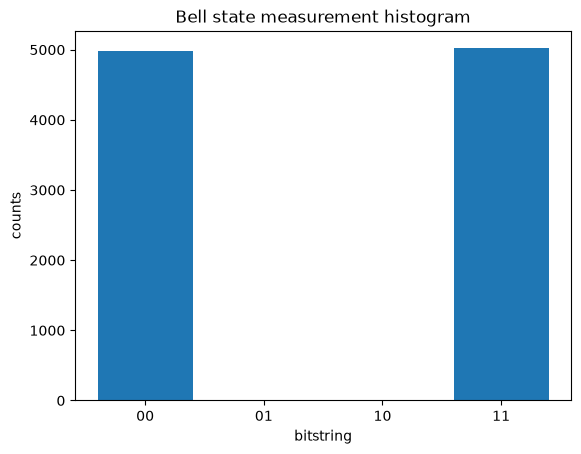

In [5]:
import matplotlib.pyplot as plt

BITSTR = ["00","01","10","11"]

def sample_bitstrings(psi: np.ndarray, shots: int = 10_000, seed: int = 7):
    rng = np.random.default_rng(seed)
    probs = np.abs(psi)**2
    idx = rng.choice(4, size=shots, p=probs)
    return idx

# Sample from Bell state
shots = 10_000
idx = sample_bitstrings(psi_bell, shots=shots)

# Make histogram
counts = {b: int(np.sum(idx == i)) for i, b in enumerate(BITSTR)}
print(counts)
plt.bar(counts.keys(), counts.values())
plt.xlabel("bitstring"); plt.ylabel("counts"); plt.title("Bell state measurement histogram")
plt.show()

**Task 1.4 — Do the counts match expectations within sampling error?**

Yes. The observed counts are:

| Bitstring | Theoretical probability | Expected count | Observed count |
| --- | ---: | ---: | ---: |
| 00 | 0.5 | 5000 | 4983 |
| 01 | 0 | 0 | 0 |
| 10 | 0 | 0 | 0 |
| 11 | 0.5 | 5000 | 5017 |

The counts for `00` and `11` are close to the expected equal split. Small deviations are normal when sampling a finite number of measurements. Outcomes `01` and `10` are absent, as expected.

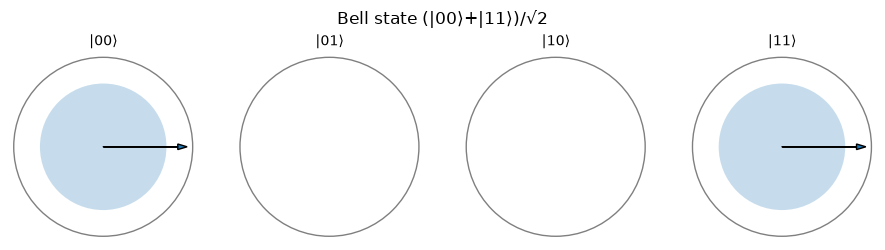

In [6]:
def sv_from_circ(circ: QuantumCircuit) -> np.ndarray:
    sv = Statevector(circ)
    return np.asarray(sv, dtype=np.complex128)

class QubitSystem:
    def __init__(self, statevector: np.ndarray, label: str = "Qubit System"):
        self.label = label
        self.set_statevector(statevector)

    def set_statevector(self, statevector: np.ndarray):
        sv = np.asarray(statevector, dtype=np.complex128)
        if sv.ndim != 1:
            raise ValueError("Statevector must be 1D.")
        n_states = sv.size
        if n_states == 0 or not np.all(np.isfinite(sv)):
            raise ValueError("Statevector must be nonempty and finite.")
        n_qubits = int(round(math.log2(n_states)))
        if 2**n_qubits != n_states:
            raise ValueError("Length must be a power of 2.")
        # Defensive normalization (harmless if already normalized)
        norm = np.linalg.norm(sv)
        if norm == 0 or not np.isfinite(norm):
            raise ValueError("Statevector must have a finite, nonzero norm.")
        sv = sv / norm

        self.n_qubits = n_qubits
        self.n_states = n_states
        self.amps  = sv
        self.prob  = np.abs(sv)**2
        self.phase = np.angle(sv)

    def viz_circle(self, max_cols: int = 8, figsize_scale: float = 2.3):
        cols = max(1, min(max_cols, self.n_states))
        rows = int(math.ceil(self.n_states / cols))

        fig, axes = plt.subplots(
            rows, cols, squeeze=False,
            figsize=(cols*figsize_scale, rows*(figsize_scale+0.2))
        )

        def bitstr(i: int, n: int) -> str:
            return format(i, f"0{n}b")

        for idx in range(rows * cols):
            r, c = divmod(idx, cols)
            ax = axes[r, c]
            ax.set_aspect("equal")
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            ax.axis("off")

            if idx >= self.n_states:
                ax.set_visible(False)
                continue

            # Outer reference circle
            ax.add_patch(plt.Circle((0.5, 0.5), 0.48, fill=False, lw=1.0, alpha=0.5))

            # Filled disk: radius ∝ sqrt(probability) so area ∝ probability
            radius = 0.48 * np.sqrt(self.prob[idx])
            ax.add_patch(plt.Circle((0.5, 0.5), radius, alpha=0.25))

            # Zero amplitudes have no defined phase.
            if self.prob[idx] > 0:
                angle = self.phase[idx]
                L = 0.45
                x2 = 0.5 + L * np.cos(angle)
                y2 = 0.5 + L * np.sin(angle)
                ax.arrow(0.5, 0.5, x2 - 0.5, y2 - 0.5,
                         head_width=0.03, head_length=0.05, length_includes_head=True)

            ax.set_title(f"|{bitstr(idx, self.n_qubits)}⟩", fontsize=10)

        fig.suptitle(self.label, fontsize=12)
        plt.tight_layout()
        plt.show()

QubitSystem(psi_bell, label="Bell state (|00⟩+|11⟩)/√2").viz_circle()

**Task 1.4:  How does the circle plot show two dominant components |00> and |11> and their relative phase?**

Each position represents one computational basis state. In `viz_circle`, the filled radius is proportional to $\sqrt{p_i}=|\psi_i|$, so the filled area is proportional to the probability $p_i$. The circles for $|00\rangle$ and $|11\rangle$ therefore have equal filled area, each representing probability $1/2$. The positions for $|01\rangle$ and $|10\rangle$ have zero filled area.
The arrows encode $\arg(\psi_i)$. Both nonzero Bell amplitudes are real and positive, so both arrows point to the right: their relative phase is zero. Zero amplitudes have no defined phase and are drawn without arrows. A global phase would rotate both nonzero arrows by the same amount without changing their relative phase or measurement probabilities. 

## 6. SWAP test: setup — Task 2

The objective is to infer the fidelity between two normalized pure one-qubit states and compare it with the direct inner product:

$$
F=|\langle\psi|\phi\rangle|^2,\qquad
P(1)=\frac{1-F}{2},\qquad F=1-2P(1).
$$

In [7]:
def expand_1q_n(U: np.ndarray, t: int, n: int) -> np.ndarray:
    op = np.array([[1]], dtype=U.dtype)
    for q in range(n):
        op = np.kron(op, U if q == t else I2)
    return op

# Apply CSWAP, with ancilla as control
P0 = np.array([[1,0],[0,0]], dtype=DTYPE)  # |0><0| on ancilla
P1 = np.array([[0,0],[0,1]], dtype=DTYPE)  # |1><1| on ancilla
SWAP_A0_B0 = np.array([
    [1,0,0,0],
    [0,0,1,0],
    [0,1,0,0],
    [0,0,0,1]
], dtype=DTYPE)  # SWAP on A0 and B0
CSWAP = (np.kron(P0, np.eye(4)) + np.kron(P1, SWAP_A0_B0)) # CSWAP with ancilla as control

In [8]:
psi = np.array([1, 0], dtype=DTYPE)
phi = np.array([0, 1], dtype=DTYPE)
assert np.isclose(np.linalg.norm(psi), 1.0)
assert np.isclose(np.linalg.norm(phi), 1.0)
init = np.kron(np.array([1,0], dtype=DTYPE), np.kron(psi, phi))  
U_Ho = expand_1q_n(H, t=0, n=3)
state = U_Ho @ init
state = CSWAP @ state
state = U_Ho @ state

probs = np.abs(state)**2
prob_1 = probs[4:].sum()   # indices with output=1
F_hat = 1 - 2*prob_1
F_exact = float(np.abs(np.vdot(psi/np.linalg.norm(psi), phi/np.linalg.norm(phi)))**2)

assert np.isclose(np.sum(np.abs(state)**2), 1.0)
assert np.isclose(F_hat, F_exact)
print(F_hat, F_exact)

######################
psi = np.array([1, 0], dtype=DTYPE)
phi = np.array([1, 0], dtype=DTYPE)
assert np.isclose(np.linalg.norm(psi), 1.0)
assert np.isclose(np.linalg.norm(phi), 1.0)

init = np.kron(np.array([1,0], dtype=DTYPE), np.kron(psi, phi))  
U_Ho = expand_1q_n(H, t=0, n=3)
state = U_Ho @ init
state = CSWAP @ state
state = U_Ho @ state

probs = np.abs(state)**2
prob_1 = probs[4:].sum()   
F_hat = 1 - 2*prob_1
F_exact = float(np.abs(np.vdot(psi/np.linalg.norm(psi), phi/np.linalg.norm(phi)))**2)
assert np.isclose(np.sum(np.abs(state)**2), 1.0)
assert np.isclose(F_hat, F_exact)
print(F_hat, F_exact)

######################
psi = np.array([1, 1], dtype=DTYPE) / np.sqrt(2)
phi = np.array([1, 0], dtype=DTYPE)
assert np.isclose(np.linalg.norm(psi), 1.0)
assert np.isclose(np.linalg.norm(phi), 1.0)

init = np.kron(np.array([1,0], dtype=DTYPE), np.kron(psi, phi)) 
U_Ho = expand_1q_n(H, t=0, n=3)
state = U_Ho @ init
state = CSWAP @ state
state = U_Ho @ state

probs = np.abs(state)**2
prob_1 = probs[4:].sum()  
F_hat = 1 - 2*prob_1
F_exact = float(np.abs(np.vdot(psi/np.linalg.norm(psi), phi/np.linalg.norm(phi)))**2)
assert np.isclose(np.sum(np.abs(state)**2), 1.0)
assert np.isclose(F_hat, F_exact)
print(F_hat, F_exact)

4.440892098500626e-16 0.0
1.0 1.0
0.5000000000000002 0.5000000000000001


**Task 2 — Report F_hat versus F_exact for at least three pairs.**

| Input psi | Input phi | P(output=1) | F_hat from SWAP test | F_exact from inner product |
| --- | --- | ---: | ---: | ---: |
| $\lvert 0\rangle$ | $\lvert 1\rangle$ | 0.5 | 0 | 0 |
| $\lvert 0\rangle$ | $\lvert 0\rangle$ | 0 | 1 | 1 |
| $\lvert +\rangle$ | $\lvert 0\rangle$ | 0.25 | 0.5 | 0.5 |

Values are rounded for readability. In the first case the printed `F_hat` is about $4.44\times10^{-16}$, which is numerical roundoff around zero. `np.vdot` conjugates the first vector, giving the correct complex inner product. The input and final-state normalization checks pass, as do all three fidelity comparisons.

**How does the output bit encode overlap?**

After H–CSWAP–H, the joint state is

$$
\frac{1}{2}|0\rangle\bigl(|\psi\rangle|\phi\rangle+|\phi\rangle|\psi\rangle\bigr)
+\frac{1}{2}|1\rangle\bigl(|\psi\rangle|\phi\rangle-|\phi\rangle|\psi\rangle\bigr)
$$

The probability of measuring 1 on the output qubit is $P(1)=(1-F)/2$. The larger the overlap, the less likely we are to measure 1. For the three pairs above, identical inputs give $P(1)=0$, orthogonal inputs give $P(1)=1/2$, and the partially overlapping states $|+\rangle$ and $|0\rangle$ give $P(1)=1/4$. A single measurement of 0 does not prove that the inputs are identical, because different states can also give this result.

## Bonus 1 — Basis-state comparison (Task B.1)

### Short Introduction

The reference register is prepared in $|5\rangle = |101\rangle$, while the test register is prepared in a computational basis state $|k\rangle$, with $k \in \{0,\ldots,7\}$. 

We first implement the standard multiqubit SWAP test using one shared output ancilla, and then investigate an alternative pairwise control distribution.

### Standard solution: Multiqubit SWAP test

#### Code

In [19]:
def fidelity(u, v):
    u = u / np.linalg.norm(u)
    v = v / np.linalg.norm(v)
    return float(np.abs(np.vdot(u, v))**2)


def build_swap_test(k):
    n = 3
    reference_k = 5  # |101>
    reference = QuantumRegister(n, "reference")
    test = QuantumRegister(n, "test")
    output = QuantumRegister(1, "output")
    result = ClassicalRegister(1, "result")
    circuit = QuantumCircuit(reference, test, output, result)

    for i in range(n):
        if (reference_k >> i) & 1:
            circuit.x(reference[i])
        if (k >> i) & 1:
            circuit.x(test[i])

    circuit.h(output[0])
    for i in range(n):
        circuit.ccx(output[0], reference[i], test[i])
        circuit.ccx(output[0], test[i], reference[i])
        circuit.ccx(output[0], reference[i], test[i])
    circuit.h(output[0])
    circuit.measure(output[0], result[0])
    return circuit


#### Sanity checks and validation

In [20]:
# Deterministic correctness check for every computational-basis test state.
for k in range(8):
    exact_circuit = build_swap_test(k).remove_final_measurements(inplace=False)
    output_index = exact_circuit.find_bit(exact_circuit.qregs[2][0]).index
    exact_p1 = Statevector.from_instruction(exact_circuit).probabilities([output_index])[1]
    assert np.isclose(1 - 2 * exact_p1, int(k == 5), atol=1e-12)

simulator = AerSimulator()
shots_bonus = 10_000
for k in [5, 0]:
    circuit = transpile(build_swap_test(k), simulator)
    counts = simulator.run(circuit, shots=shots_bonus, seed_simulator=7).result().get_counts()
    p1 = counts.get("1", 0) / shots_bonus
    estimated = 1 - 2 * p1
    expected = 1 if k == 5 else 0
    print("k =", k, "Estimated fidelity:", round(estimated, 3), "Expected:", expected)
    if k == 5:
        # Ideal identical inputs have P(1)=0, hence no shot noise.
        assert counts.get("1", 0) == 0
    else:
        # For orthogonal inputs, SE(F_hat)=1/sqrt(shots).
        # Five standard errors give a generous sampling sanity check;
        # the exact check above establishes circuit correctness.
        assert abs(estimated - expected) <= 5 / np.sqrt(shots_bonus)

k = 5 Estimated fidelity: 1.0 Expected: 1
k = 0 Estimated fidelity: 0.002 Expected: 0


#### Circuit diagram

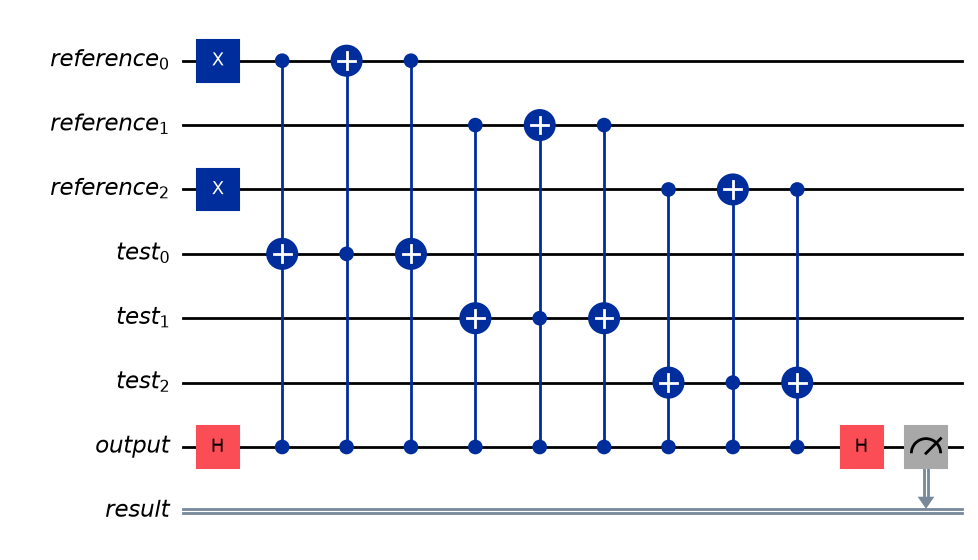

In [28]:
# Circuit diagram of the standard multiqubit SWAP test.
# k = 0 is used only as an illustrative example against the reference |101>.

example_swap_circuit = build_swap_test(k=0)

example_swap_circuit.draw(output="mpl", fold=-1, cregbundle=False)

#### Design discussion

The standard circuit uses a single output qubit as a shared control for all three matched pairs $(R_i,T_i)$. After preparing the reference register in $|5\rangle=|101\rangle$ and the test register in $|k\rangle$, a Hadamard gate is applied to the output qubit. The controlled exchange is then performed independently on each of the three matched pairs, but all exchanges are conditioned on the same output qubit. Finally, a second Hadamard is applied to the output qubit and only this qubit is measured. Its measurement probability is used to estimate the global fidelity according to the required convention
$$
\hat F = 1 - 2\hat P(\mathrm{output}=1).
$$

For simplicity, each controlled exchange was implemented by starting from the three CNOT decomposition of a SWAP operation and adding the output qubit as an additional control. Each CNOT therefore becomes a CCX gate. Since there are three matched qubit pairs, the complete exchange requires $3\times3=9$ CCX gates. The circuit also uses two Hadamard gates and one measurement, for a total of seven qubits: three reference qubits, three test qubits, and one output ancilla. At this logical level, no explicit two qubit gates are used in the controlled exchange. However, CCX is itself a three qubit operation and will generally be decomposed by the transpiler into native one and two qubit gates.

This implementation is intentionally simple rather than optimal for resources. One limitation is that the same output qubit participates in every controlled exchange, so the nine CCX operations cannot all be executed in parallel at the logical level. This can increase circuit depth compared with a design using independent output ancillas. On the other hand, the shared control design uses fewer qubits and classical bits and, most importantly, directly implements the multiqubit SWAP test: the measured output encodes the overlap of the complete three qubit states rather than separate local overlaps. Therefore, unlike the parallel pairwise variant considered later, this method remains conceptually valid for general multiqubit states, including states that are not separable into independent single qubit factors.

### Alternative design: Parallel pairwise SWAP tests

As an additional experiment, we replace the shared output ancilla with one output qubit for each matched pair $(R_i,T_i)$. 

This produces three local SWAP test measurements rather than measuring the global three qubit overlap directly.

#### Code

In [21]:
N_QUBITS = 3
REFERENCE_K = 5  # |101>


# Append a controlled SWAP using three Toffoli (CCNOT) gates.
def append_controlled_swap(circuit, control, qubit_a, qubit_b):
    circuit.ccx(control, qubit_a, qubit_b)
    circuit.ccx(control, qubit_b, qubit_a)
    circuit.ccx(control, qubit_a, qubit_b)


# Build n independent pairwise SWAP tests.
def build_parallel_swap_tests(k, n=N_QUBITS, reference_k=REFERENCE_K):
    reference = QuantumRegister(n, "reference")
    test = QuantumRegister(n, "test")
    output = QuantumRegister(n, "output")
    result = ClassicalRegister(n, "result")

    circuit = QuantumCircuit(reference, test, output, result)

    # Prepare |reference_k> and |k>.
    # Qiskit register index 0 corresponds to the least significant bit.
    for i in range(n):
        if (reference_k >> i) & 1:
            circuit.x(reference[i])

        if (k >> i) & 1:
            circuit.x(test[i])

    # One independent SWAP test for each matched qubit pair.
    for i in range(n):
        circuit.h(output[i])

        append_controlled_swap(circuit, output[i], reference[i], test[i])

        circuit.h(output[i])
        circuit.measure(output[i], result[i])

    return circuit

# Estimate output and corresponding local fidelity
def estimate_local_fidelities(counts, n=N_QUBITS):
    total_shots = sum(counts.values())
    count_ones = np.zeros(n, dtype=int)

    for bitstring, count in counts.items():
        # Qiskit prints classical bits with the highest index on the left.
        # Reversing gives bits[i] <-> result[i].
        bits = bitstring.replace(" ", "")[::-1]

        for i, bit in enumerate(bits):
            if bit == "1":
                count_ones[i] += count

    p1 = count_ones / total_shots
    local_fidelity = 1 - 2 * p1

    return p1, local_fidelity

# Fidelities for computational basis states
def expected_local_fidelities(k, n=N_QUBITS, reference_k=REFERENCE_K):
    return np.array(
        [float(((reference_k >> i) & 1) == ((k >> i) & 1)) for i in range(n)]
    )

#### Circuit diagram

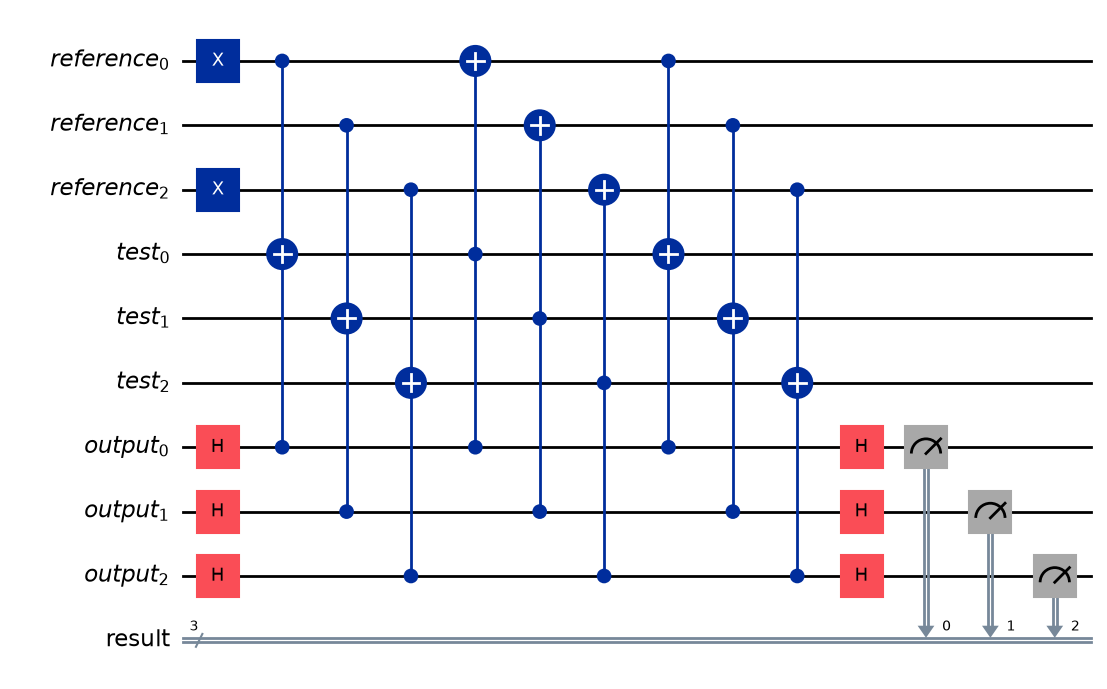

In [22]:
example_parallel_circuit = build_parallel_swap_tests(k=0)
example_parallel_circuit.draw("mpl")

#### Sanity checks and validation

In [23]:
simulator = AerSimulator()

SHOTS = 10_000
SEED = 7

print(f"Reference state: |{REFERENCE_K:03b}>")
print()

for k in range(2**N_QUBITS):
    circuit = build_parallel_swap_tests(k)
    compiled = transpile(circuit, simulator)

    counts = simulator.run(
        compiled,
        shots=SHOTS,
        seed_simulator=SEED
    ).result().get_counts()

    p1, local_fidelity = estimate_local_fidelities(counts)
    expected_local = expected_local_fidelities(k)

    # For these product basis states, the exact global fidelity factorizes.
    # The product of the sampled local estimates is shown only as a diagnostic.
    local_product = np.prod(local_fidelity)
    exact_global = float(k == REFERENCE_K)

    # Sampling sanity checks.
    for i in range(N_QUBITS):
        if expected_local[i] == 1:
            # Equal basis state qubits give P(1)=0 exactly.
            assert np.isclose(local_fidelity[i], 1.0)
        else:
            # For different basis state qubits, F_i = 0 and
            # SE(F_i) = 1/sqrt(shots).
            assert abs(local_fidelity[i]) <= 5 / np.sqrt(SHOTS)

    print(
        f"k = {k} (|{k:03b}>) | "
        f"F0 = {local_fidelity[0]: .3f}, "
        f"F1 = {local_fidelity[1]: .3f}, "
        f"F2 = {local_fidelity[2]: .3f} | "
        f"product(local estimates) = {local_product: .3f} | "
        f"exact global F = {exact_global:.0f}"
    )

Reference state: |101>



k = 0 (|000>) | F0 =  0.003, F1 =  1.000, F2 =  0.002 | product(local estimates) =  0.000 | exact global F = 0
k = 1 (|001>) | F0 =  1.000, F1 =  1.000, F2 =  0.002 | product(local estimates) =  0.002 | exact global F = 0
k = 2 (|010>) | F0 = -0.012, F1 =  0.003, F2 =  0.002 | product(local estimates) = -0.000 | exact global F = 0
k = 3 (|011>) | F0 =  1.000, F1 =  0.003, F2 =  0.002 | product(local estimates) =  0.000 | exact global F = 0
k = 4 (|100>) | F0 =  0.002, F1 =  1.000, F2 =  1.000 | product(local estimates) =  0.002 | exact global F = 0
k = 5 (|101>) | F0 =  1.000, F1 =  1.000, F2 =  1.000 | product(local estimates) =  1.000 | exact global F = 1
k = 6 (|110>) | F0 =  0.003, F1 =  0.002, F2 =  1.000 | product(local estimates) =  0.000 | exact global F = 0
k = 7 (|111>) | F0 =  1.000, F1 =  0.002, F2 =  1.000 | product(local estimates) =  0.002 | exact global F = 0


#### Design discussion 

In the standard implementation above, a single output qubit controls the exchanges of all three matched pairs. As an alternative, we tested a distributed control architecture in which each pair $(R_i,T_i)$ has its own output ancilla. Each ancilla undergoes its own H controlled exchange H sequence and is measured independently. With the chosen exchange decomposition, each pair requires three CCX gates. The complete parallel circuit therefore uses 9 qubits, 9 CCX gates, 6 Hadamard gates, and 3 measurements. In comparison, the single output implementation uses 7 qubits, the same 9 CCX gates, only 2 Hadamard gates, and one measurement.

The main advantage of the parallel design is that the three controlled exchanges act on disjoint sets of qubits. At the logical level, the three first CCX gates can therefore be executed in parallel, followed by the three second CCX gates and then the three third CCX gates. This trades two additional ancilla qubits for potentially smaller circuit depth. It also provides more information than the single output circuit: the three estimated fidelities identify which individual qubit pairs agree or disagree. For example, comparing $|101\rangle$ with $|100\rangle$ gives approximately $F_0=0$, $F_1=1$, and $F_2=1$, revealing that only the least significant pair differs. The actual transpiled depth on physical hardware would, however, depend on the native gate set, connectivity, and decomposition of the CCX gates, so the logical depth advantage should not be interpreted as a hardware independent result.

A limitation is that these three quantities are local fidelities, not a direct measurement of the global three qubit fidelity. For the computational basis states used in Task B.1, both registers are product states, so
$$
F_{\mathrm{global}} = F_0F_1F_2.
$$
Therefore, in this particular experiment the local results are sufficient to recover the same exact global comparison: all three local fidelities are one only for $k=5$, while at least one of them is zero for every $k\neq5$. However, this factorization cannot in general be assumed for arbitrary multiqubit states, especially entangled states. For this reason, we keep the single output multiqubit SWAP test as the main implementation required by the task and treat the parallel circuit as an alternative design used to study resource and information trade offs.

The small positive or negative values observed around zero for mismatching pairs are caused by finite shot sampling. For a mismatching computational basis pair, the exact probabilities are $P(0)=P(1)=1/2$, so the estimator
$$
\hat F_i = 1-2\hat P_i(1)
$$
fluctuates around zero. A slightly negative estimated value is therefore a sampling artifact rather than a negative physical fidelity. Equal pairs instead have $P(1)=0$, so in the ideal simulator their estimated fidelity remains exactly one even with a finite number of shots.

**B.2 - Introducing Superposition**

**Do some negatives ($k\ne5$) show larger $\hat{F}$? If yes, explain why. Relate this to how fidelity encodes overlap.**

Some negative cases report a larger estimated fidelity. This depends on the distance between the reference vector and the test vector. In this setup, the least significant bit of the test vector is in a superposition state, which places the register halfway between $|100\rangle$ and $|101\rangle$.

**Would it still be possible to determine whether $k=5$ using the strategy proposed in B.1? Explain why or why not.**

No, it would not be possible, because the fidelity cannot be 1 when the first bit of the reference vector is in a superposition state.